# O2 Rich Sub Neptune Case: Searching for Ozone

In [3]:
import sys
from pathlib import Path

_root = Path.cwd()  # assumes notebook is run from the project root
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))
sys.path.insert(0, str(_root / 'ReflectedSpectra_Scripts'))

import matplotlib.pyplot as plt
import numpy as np
import heapq

import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
import FinalPaperFigures_RLSChanges as final_paper_figures
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path

current_directory = Path.cwd()
references_directory_path = "Installation_Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation_Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi


/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Install

In [3]:
def Photochem_called(rad_plan=None, log10_planet_metallicity=None, tint=None, semi_major=None, ctoO=None, log_Kzz=None, PIC_PT=None, outputfile=None):
    # Planet Parameters
    atoms_names = ['H', 'He', 'N', 'O', 'C'] # We select a subset of the atoms in zahnle_earth.yaml (leave out Cl), remove Sulpher for faster convergence

    # Calculate the Mass of the Planet and Teq
    mass_planet_earth = picaso_grid.mass_from_radius_chen_kipping_2017(R_rearth=rad_plan)
    mass_planet = mass_planet_earth * (5.972e+24) * 1e3 # of planet, but in grams
    radius_planet = rad_plan * (6.371e+6) * 1e2 # of planet but in cm
    solar_zenith_angle = 60 # Used in Tsai et. al. (2023), in degrees
    planet_Teq = picaso_grid.calc_Teq_SUN(distance_AU=semi_major)

    # Dependent constant variables
    if os.path.exists(f'sun_flux_file_{planet_Teq}'):
        stellar_flux_file = f'sun_flux_file_{planet_Teq}'
        print(f"The stellar flux file already exists")
    else:
        wv, F = star_spectrum.solar_spectrum(Teq=planet_Teq, outputfile= f'sun_flux_file_{planet_Teq}')
        stellar_flux_file = f'sun_flux_file_{planet_Teq}'

    pressure = PIC_PT['pressure']
    temperature = PIC_PT['temperature']
    PT_list = np.array([pressure, temperature]) 

    # Test Data - This works fine.
    #with open('out_Sun_5778_initp3bar.pkl', 'rb') as file:
    #    out_reopened = pickle.load(file)
    #    pressure = out_reopened['pressure']
    #    temperature = out_reopened['temperature']
    #PT_list = np.array(pressure), np.array(temperature)
    #convergence_values = np.array([1])

    # Define P-T Profile (convert from PICASO to Photochem)
    P_extended, T_extended = photochem_grid.linear_extrapolate_TP(PT_list[0], PT_list[1]) # Extend the end to bypass BOA Error of mismatching boundary conditions.
    #P = np.flip(np.array(PT_list[0]) * (10**6)).copy()
    #T = np.flip(np.array(PT_list[1])).copy()
    P = np.flip(np.array(P_extended) * (10**6)).copy() # Convert from bars to dynes/cm^2
    T = np.flip(np.array(T_extended)).copy()
    
    # Check if numpy array is sorted (investigating error)
    sorted_P = np.flip(np.sort(P)).copy()
    unsorted_indices = np.where(P != sorted_P)[0]
    
    # Generate reaction & thermodynamic files for gas giants
    photochem_grid.zahnle_rx_and_thermo_files(
    atoms_names=atoms_names,
    rxns_filename='photochem_rxns.yaml',
    thermo_filename='photochem_thermo.yaml',
    remove_reaction_particles=True # For gas giants, we should always leave out reaction particles.
    )

    # Initialize ExoAtmosphereGasGiant
    # Assigns 
    pc = photochem_grid.gasgiants.EvoAtmosphereGasGiant(
        mechanism_file='photochem_rxns.yaml',
        stellar_flux_file=stellar_flux_file,
        planet_mass=mass_planet,
        planet_radius=radius_planet,
        solar_zenith_angle=solar_zenith_angle,
        thermo_file='photochem_thermo.yaml'
    )
    # Adjust convergence parameters:
    pc.var.conv_longdy = 0.03 # converges at 3% (change of mixing ratios over long time)
    pc.gdat.max_total_step = 10000 # assumes convergence after 10,000 steps
    
    pc.gdat.verbose = True # printing
    
    # Define the host star composition
    molfracs_atoms_sun = np.ones(len(pc.gdat.gas.atoms_names))*1e-10 # This is for the Sun
    comp = {
        'H' : 9.21e-01,
        'N' : 6.23e-05,
        'O' : 4.51e-04,
        'C' : 2.48e-04,
        'S' : 1.21e-05,
        'He' : 7.84e-02
    }

    tot = sum(comp.values())
    for key in comp:
        comp[key] /= tot
    for i,atom in enumerate(pc.gdat.gas.atoms_names):
        molfracs_atoms_sun[i] = comp[atom]
    
    pc.gdat.gas.molfracs_atoms_sun = molfracs_atoms_sun

    # Assume a default radius for particles 1e-5cm was default, so we increased the size but think of these in microns
    particle_radius = pc.var.particle_radius
    particle_radius[:,:] = 1e-3 #cm or 10 microns
    pc.var.particle_radius = particle_radius

    # Assumed Kzz (cm^2/s) in Tsai et al. (2023)
    Kzz_zero_grid = np.ones(P.shape[0])
    Kzz = Kzz_zero_grid*(10**log_Kzz) #Note Kzz_fac was meant to be the power of 10 since we are in log10 space

    # Initialize the PT based on chemical equilibrium 
    pc.gdat.BOA_pressure_factor = 3
    pc.initialize_to_climate_equilibrium_PT(P, T, Kzz, 10**log10_planet_metallicity, ctoO)
    
    # Integrate to steady state
    converged = pc.find_steady_state()

    # Check if the model converged after 10,000 steps
    if not converged:
        assert pc.gdat.total_step_counter > pc.gdat.max_total_step - 10
        
    sol_raw = pc.return_atmosphere()
    soleq_raw = pc.return_atmosphere(equilibrium=True)

    # Call the interpolation of the grid 
    sol = photochem_grid.interpolate_photochem_result_to_nlayers(out=sol_raw, nlayers=100)
    soleq = photochem_grid.interpolate_photochem_result_to_nlayers(out=soleq_raw, nlayers=100)
    #convergence_values = np.array([convergence_values[0] for _ in range(len(sol['pressure']))])
    #converged = np.array([converged for _ in range(len(sol['pressure']))])

    # Print out the lengths of arrays: Save the size of the grid for future reference.

    print(f"This is for the input value of planet radius:{rad_plan}, metal:{float(log10_planet_metallicity)}, tint:{tint}, semi major:{semi_major}, ctoO: {ctoO}, log_Kzz: {log_Kzz}")
    
    #for key, value in sol.items():
    #    if isinstance(value, np.ndarray):  # Check if the value is a list (or array)
    #        print(f"The array for sol's '{key}' has a length of: {len(value)}")
    #    else:
    #        print(f"The value for sol's '{key}' is not an array.")

    #for key, value in soleq.items():
    #    if isinstance(value, np.ndarray):  # Check if the value is a list (or array)
    #        print(f"The array for soleq's '{key}' has a length of: {len(value)}, Length of pressure: {len(P)}")
    #    else:
    #        print(f"The value for soleq's '{key}' is not an array.")

    # Add nan's to fit the grid if underestimated, and make sure list goes from largest to smallest.

    if outputfile == None:
        return sol, soleq, pc

    else:
        with open(f'sol_{outputfile}.pkl', 'wb') as f:
            pickle.dump(sol, f)
        with open(f'soleq_{outputfile}.pkl', 'wb') as f:
            pickle.dump(soleq, f)
        return sol, soleq, pc

In [4]:
def find_pbot(sol=None, solaer=None, tol=0.9):

    """
    Parameters:
    pressures: ndarray
        Pressure at each atmospheric layer in dynes/cm^2
    H2Oaer: ndarray
        Mixing ratio of H2O aerosols.
    tol: float, optional
        The threshold value for which we define the beginning of the cloud, 
        by default 1e-4. 

    Returns:
    P_bottom: float
        The cloud bottom pressure in dynes/cm^2
        
    """

    pressure = sol['pressure']
    H2Oaer = solaer['H2Oaer']

    # There is no water cloud in the model, so we return None
    # For the cloud bottom of pressure

    if np.max(H2Oaer) < 1e-20:
        return None

    # Normalize so that max value is 1
    H2Oaer_normalized = H2Oaer/np.max(H2Oaer)

    # loop from bottom to top of atmosphere, cloud bottom pressure
    # defined as the index level where the normalized cloud mixing ratio
    # exeeds tol .

    ind = None
    
    for i, val in enumerate(H2Oaer_normalized):
        if val > tol:
            ind = i
            break

    if ind is None:
        raise Exception('A problem happened when trying to find the bottom of the cloud.')

    # Bottom of the cloud
    pbot = pressure[ind]

    return pbot

In [19]:
def reflected_spectrum_planet_Sun(rad_plan=None, planet_metal=None, tint=None, semi_major=None, ctoO=None, Kzz=None, phase_angle=None, sol_path=None, soleq_path=None, Photochem_file=False, atmosphere_kwargs={}, kwarg_factor=0, outputfile=None, forced_nocld=False):

    """
    This finds the reflected spectra of a planet similar to K218b around a Sun.
start_case.inputs['atmosphere']['exclude_mol'] = {'CH4': 0}
    Parameters:
    rad_plan: float
        This is the radius of the planet in units of Earth radii.
    planet_metal: float
        This is the planet's metallicity in units of log10 x Solar metallicity.
    tint: float
        This is the planet's internal temperature in Kelvin.
    semi_major: float
        This is the semi major axis of your planet's orbit in units of AU.
    ctoO: float
        This is the carbon to oxygen ratio of your planet's atmosphere in units of xSolar c/o.
    Kzz: float
        This is the eddy diffusion coefficient in logspace (i.e. the power of 10) in cm/s^2.
    phase_angle: float
        This is the phase of orbit the planet is in relative to its star and the observer (i.e. how illuminated it is), units of radians.
    Photochem_file: string
        This is the path to the Photochem grid you would like to pull composition information from.
    atmosphere_kwargs: dict 'exclude_mol': value where value is a string
        If left empty, all molecules are included, but can limit how many molecules are calculated. 

    Results: IDK for sure though
    wno: grid of 150 points
        ???
    fpfs: grid of 150 points
        This is the relative flux of the planet and star (fp/fs). 
    alb: grid of 150 points
        ???
    np.array(clouds): grid of 150 points
        This is a grid of whether or not a cloud was used to make the reflective spectra using the binary equivalent to booleans (True=1, False=0).
        
    """

    # Create and empty dictionary for later results
    
    current_directory = Path.cwd()
    opacity_file_path = "Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db"  
    opacity_path=os.path.join(current_directory, opacity_file_path)
    print(opacity_path)
    opacity = jdi.opannection(filename_db=opacity_path, wave_range=[0.1,2.5])

    planet_metal = float(planet_metal)
    
    start_case = jdi.inputs()

    # Then calculate the composition from the TP profile
    class planet:
        
        planet_radius = (rad_plan*6.371e+6*u.m) # in meters
        planet_mass = picaso_grid.mass_from_radius_chen_kipping_2017(R_rearth=rad_plan)*(5.972e+24) # in kg
        planet_Teq = picaso_grid.calc_Teq_SUN(distance_AU=semi_major) # Equilibrium temp (K)
        planet_grav = (const.G * (planet_mass)) / ((planet_radius)**2) # of K2-18b in m/s^2
        planet_ctoO = ctoO # in xSolar

    class Sun:
        
        stellar_radius = 1 # Solar radii
        stellar_Teff = 5778 # K
        stellar_metal = 0.0 # log10(metallicity)
        stellar_logg = 4.4 # log10(gravity), in cgs units

    solar_zenith_angle = 60 # Used in Tsai et al. (2023)
        
    # Star and Planet Parameters (Stay the Same & Should Match Photochem & PICASO)
    start_case.phase_angle(phase_angle, num_tangle=8, num_gangle=8) #radians, using default here

    jupiter_mass = const.M_jup.value # in kg
    jupiter_radius = 69911e+3 # in m
    start_case.gravity(gravity=planet.planet_grav, gravity_unit=jdi.u.Unit('m/(s**2)'), radius=(planet.planet_radius.value)/jupiter_radius, radius_unit=jdi.u.Unit('R_jup'), mass=(planet.planet_mass)/jupiter_mass, mass_unit=jdi.u.Unit('M_jup'))
    
    # star temperature, metallicity, gravity, and opacity (default opacity is opacity.db in the reference folder)
    start_case.star(opannection=opacity, temp=Sun.stellar_Teff, logg=Sun.stellar_logg, semi_major=semi_major, metal=Sun.stellar_metal, radius=Sun.stellar_radius, radius_unit=jdi.u.R_sun, semi_major_unit=jdi.u.au)

    # Match Photochemical Files
    if Photochem_file is not True:
        sol_dict, soleq_dict, PT_list, convergence_PC, convergence_TP = Reflected_Spectra.find_Photochem_match(filename=Photochem_file, rad_plan=rad_plan, log10_planet_metallicity=planet_metal, tint=tint, semi_major=semi_major, ctoO=ctoO,Kzz=Kzz)

    elif Photochem_file is True:
        with open(sol_path, 'rb') as file:
            sol_dict = pickle.load(file)
        with open(soleq_path, 'rb') as file:
            soleq_dict = pickle.load(file)
    
            
    # Determine Planet Atmosphere & Composition

    atm, sol_dict_aer = Reflected_Spectra.make_picaso_atm(sol_dict) # Converted Pressure of Photochem, in dynes/cm^2, back to bars and flip all arrays before placing into PICASO
    print(type(atm['pressure']))
    print(f'Length of pressure vs other element: {len(atm['pressure'])} vs {len(atm['He'])}')

    # Limit atmosphere to pressures 1000 bars and below.

    atm_filtered = {}
    
    # FIX: Limit atmosphere to temperatures 1000K and below without removing atmosphere.
    original_temp = atm['temperature'].copy()
    if temporary_temp_fix == True:
        atm['temperature'] = np.minimum(atm['temperature'], 999.999)
        print(f"Applied temporary temperature fix: capped temperatures at 999.999 K to avoid PICASO issues with T=1000 K.")

   # Define keys to ignore
    exclude = {'pressure', 'temperature'}

    df_atmo = jdi.pd.DataFrame(atm)

    plt.gca().invert_yaxis()
    plt.semilogy(df_atmo['temperature'], df_atmo['pressure'], ls='-', c='red') 
    plt.semilogy(atm['temperature'], atm['pressure'], ls='--', c='blue')

    # 4. Customize and display
    plt.title("Filtered PT Profile")
    plt.xlabel("Temperature in K")
    plt.ylabel("Pressure in bars")
    plt.legend() # Displays the labels
    plt.show()

    if 'exclude_mol' in atmosphere_kwargs:
        for sp in atmosphere_kwargs['exclude_mol']:
            print(f'This should show the species you are excluding: {sp}')
            
            if sp in df_atmo:
                df_atmo[sp] *= kwarg_factor
                print(df_atmo[sp])
    
    start_case.atmosphere(df = df_atmo) 
    df_cldfree = start_case.spectrum(opacity, calculation='reflected', full_output=True)
    wno_cldfree, alb_cldfree, fpfs_cldfree = df_cldfree['wavenumber'], df_cldfree['albedo'], df_cldfree['fpfs_reflected']
    _, alb_cldfree_grid = jdi.mean_regrid(wno_cldfree, alb_cldfree, R=150)
    wno_cldfree_grid, fpfs_cldfree_grid = jdi.mean_regrid(wno_cldfree, fpfs_cldfree, R=150)

    print(f'This is the length of the grids created: {len(wno_cldfree_grid)}, {len(fpfs_cldfree_grid)}')

    # Determine Whether to Add Clouds or Not?

    if "H2Oaer" in sol_dict_aer and forced_nocld == False:
        # What if we added Grey Earth-like Clouds?
        
        # Calculate pbot:
        pbot = find_pbot(sol = atm, solaer=sol_dict_aer)

        if pbot is not None:
            print(f'pbot was calculated, there is H2Oaer and a cloud was implemented')
            logpbot = np.log10(pbot)
        
            # Calculate logdp:
            ptop_earth = 0.6
            pbot_earth = 0.7
            logdp = np.log10(pbot_earth) - np.log10(ptop_earth)  
    
            # Default opd (optical depth), w0 (single scattering albedo), g0 (asymmetry parameter)
            start_case.clouds(w0=[0.99], g0=[0.85], 
                              p = [logpbot], dp = [logdp], opd=[10])
            # Cloud spectrum
            df_cld = start_case.spectrum(opacity,full_output=True)
            
            # Average the two spectra - This differs between Calculating Earth Reflected Spectra 
            wno_c, alb_c, fpfs_c, albedo_c = df_cld['wavenumber'],df_cld['albedo'],df_cld['fpfs_reflected'], df_cld['albedo']
            _, alb = jdi.mean_regrid(wno_cldfree, 0.25*alb_cldfree+0.75*albedo_c,R=150)
            wno, fpfs = jdi.mean_regrid(wno_cldfree, 0.25*fpfs_cldfree+0.75*fpfs_c,R=150)

            # Match the length of the clouds array with the length of wno or alb (fpfs is different length)
            clouds = [1] * len(wno)

            
            if outputfile == None:
                return wno, fpfs, alb, np.array(clouds), df_cld, df_cldfree
            else:
                outputfile_name = outputfile
                RSM_outputs = {"wno":wno,
                               "fpfs":fpfs,
                               "alb":alb,
                               "clouds":np.array(clouds),
                               "df_cld":df_cld,
                               "df_cldfree":df_cldfree}
                
                with open(f'RLS_{outputfile_name}.pkl', 'wb') as f:
                    pickle.dump(RSM_outputs, f)
                return wno, fpfs, alb, np.array(clouds), df_cld, df_cldfree

        else:
            print(f'pbot is empty and/or forced_nocld is False, so no cloud is implemented')
            wno = wno_cldfree_grid.copy()
            alb = alb_cldfree_grid.copy()
            fpfs = fpfs_cldfree_grid.copy()

            # Match the length of the clouds array with the length of wno or alb (fpfs is different length)
            clouds = [0] * len(wno)

            print(f'This is the length of the values I want to save: wno {len(wno)}, alb {len(alb)}, fpfs {len(fpfs)}, clouds {len(clouds)}')

            if outputfile == None:
                return wno, fpfs, alb, np.array(clouds), df_cld, df_cldfree
            else:
                outputfile_name = outputfile
                RSM_outputs = {"wno":wno,
                               "fpfs":fpfs,
                               "alb":alb,
                               "clouds":np.array(clouds),
                               "df_cld":df_cld,
                               "df_cldfree":df_cldfree}
                
                with open(f'RLS_{outputfile_name}.pkl', 'wb') as f:
                    pickle.dump(RSM_outputs, f)
                return wno, fpfs, alb, np.array(clouds), df_cld, df_cldfree

    else:
        print(f'H2Oaer is not in solutions')
        wno = wno_cldfree_grid.copy()
        alb = alb_cldfree_grid.copy()
        fpfs = fpfs_cldfree_grid.copy()
        print(f'For the inputs: {rad_plan}, {planet_metal}, {tint}, {semi_major}, {ctoO}, {Kzz}, {phase_angle}, The length should match: wno - {len(wno)}, alb - {len(alb)}, fpfs - {len(fpfs)}')
        
        # Match the length of the clouds array with the length of wno or alb (fpfs is different length)
        clouds = [0] * len(wno) # This means that there are no clouds

        df_cld = None

        if outputfile == None:
                return wno, fpfs, alb, np.array(clouds), df_cld, df_cldfree
        else:
            outputfile_name = outputfile
            RSM_outputs = {"wno":wno,
                           "fpfs":fpfs,
                           "alb":alb,
                           "clouds":np.array(clouds),
                           "df_cld":df_cld,
                           "df_cldfree":df_cldfree}
            
            with open(f'RLS_{outputfile_name}.pkl', 'wb') as f:
                pickle.dump(RSM_outputs, f)
                
            return wno, fpfs, alb, np.array(clouds), df_cld, df_cldfree

## Mini-Neptune Interesting Case

Parameters:
- planet radius: 2.61x Earth
- **metallicity: 3.5x (logspace) x solar (~3000x solar metallicity)**
- tint: 155K
- semi major in AU: 1 AU
- **ctoO_solar: 0.01 x solar c/o ratio**

## Load PICASO Model

In [13]:
file_path = "individual_rerun_data/grid_results/out_3.5m_0.01co.pkl"
with open(file_path, 'rb') as file:
    data_35m_001co = pickle.load(file)
    

## Load/Run Photochemical Model

In [7]:
rad_plan = 2.61
log10_metal = 3.5
tint = 155
semi_major = 1
ctoO = 0.01
Kzz = 5
outfile = f'{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}'

# Save to file above!
# sol, soleq, pc = Photochem_called(rad_plan=rad_plan, log10_planet_metallicity=log10_metal, tint=tint, semi_major=semi_major, ctoO=ctoO, log_Kzz=Kzz, PIC_PT=data_35m_001co)

In [14]:
sol_file_path = "individual_rerun_data/grid_results/sol_2.61_3.5_155_1_0.01_5.pkl"
soleq_file_path = "individual_rerun_data/grid_results/soleq_2.61_3.5_155_1_0.01_5.pkl"

with open(sol_file_path, 'rb') as file:
    photochem_data_35m_001co_sol = pickle.load(file)
    print(photochem_data_35m_001co_sol.keys())

with open(soleq_file_path, 'rb') as file:
    photochem_data_35m_001co_soleq = pickle.load(file)
    print(photochem_data_35m_001co_soleq.keys())

dict_keys(['pressure', 'temperature', 'Kzz', 'H2Oaer', 'CO2aer', 'NH3aer', 'N2Oaer', 'C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'HCCCNaer', 'HCNaer', 'CH4aer', 'He', 'H', 'H2', 'H2O', 'OH', 'O', 'O2', 'CO', 'CO2', 'HCO', 'H2CO', 'C', 'CH', 'CH2', 'CH3', 'CH4', 'CN', 'HCN', 'N', 'N2', 'NH', 'NH2', 'NH3', 'C2', 'C2H', 'C2H2', 'C2H4', 'NO', 'HNO', 'HO2', 'HNCO', 'N2O', 'H2O2', 'O3', 'NO2', 'NO3', 'HNO2', 'HNO3', 'N2H4', 'C2H6', 'CH3OH', 'CH2CO', 'CH3CHO', 'C3H4', 'C3H6', 'C4H2', 'C4H4', 'C2H3', 'C2H5', 'NCO', '1CH2', 'HCCO', 'NNH', 'CH3O', 'H2COH', 'H2CN', 'N2H2', 'C4H', 'HCNOH', 'C2H2OH', 'CH3CO', 'CH2CHO', 'C2H3OH', 'C2H4OH', 'CH3O2', 'O1D', 'N2H3', 'NH2CO', 'C4H3', 'CH2N2', 'N2D', 'CH2CN', 'CH3CN', 'HCCCN'])
dict_keys(['pressure', 'temperature', 'Kzz', 'He', 'H', 'H2', 'H2O', 'OH', 'O', 'O2', 'CO', 'CO2', 'HCO', 'H2CO', 'C', 'CH', 'CH2', 'CH3', 'CH4', 'CN', 'HCN', 'N', 'N2', 'NH', 'NH2', 'NH3', 'C2', 'C2H', 'C2H2', 'C2H4', 'NO', 'HNO', 'HO2', 'HNCO', 'N2O', 'H2O2', 'O3', 'NO2', 'NO3'

### Code to check abundances

In [15]:
def get_most_abundant_molecule(data_dict):
    """
    Finds the key with the highest concentration from a dictionary of arrays,
    excluding specific keywords.
    """
    # Keys to exclude
    excluded_keywords = ('aer', 'pressure', 'temperature', 'Kzz')
    
    max_abundance = -1
    most_abundant_mol = None
    
    for mol, concentrations in data_dict.items():
        # 1. Filter: Exclude keys ending in 'aer' or exact matches
        if mol.endswith('aer') or mol in excluded_keywords:
            continue
            
        # Ensure we are dealing with a numpy array for numerical operations
        conc_array = np.array(concentrations)
        
        # 2. Find max concentration for this molecule
        current_max = np.max(conc_array)
        
        # 3. Compare with overall max
        if current_max > max_abundance:
            max_abundance = current_max
            most_abundant_mol = mol
            
    return most_abundant_mol, max_abundance
    
# Execute

molecule, concentration = get_most_abundant_molecule(photochem_data_35m_001co_sol)

print(f"Most abundant molecule: {molecule}")
print(f"Total concentration/sum: {concentration:.2e}")

Most abundant molecule: O2
Total concentration/sum: 8.19e-01


In [16]:
def get_top_10_molecules(data_dict):
    # 1. Define keys to exclude
    excluded_suffixes = ('aer')
    excluded_exact = {'pressure', 'temperature', 'Kzz'}
    
    # 2. Filter the dictionary:
    # - Exclude specific exact names
    # - Exclude keys ending in 'aer'
    filtered_molecules = {}
    for key, values in data_dict.items():
        if key not in excluded_exact and not key.endswith(excluded_suffixes):
            # Assuming 'values' is an array/list of concentrations,
            # we take the max concentration for ranking.
            # Change max(values) to np.mean(values) or similar if needed.
            filtered_molecules[key] = max(values)
            
    # 3. Get top 10 using heapq for efficiency
    top_10 = heapq.nlargest(20, filtered_molecules, key=filtered_molecules.get)
    
    # 4. Return the molecules and their max concentrations
    return {molecule: filtered_molecules[molecule] for molecule in top_10}

top_molecules = get_top_10_molecules(photochem_data_35m_001co_sol)
print("Top 10 Molecules by Max Concentration:")
for mol, conc in top_molecules.items():
    print(f"{mol}: {conc}")

Top 10 Molecules by Max Concentration:
O2: 0.8190449833643952
He: 0.48089379749358974
H2O2: 0.3557172687411066
H2O: 0.30568862956127674
N2: 0.09407695465253245
NO: 0.08551575483112085
OH: 0.08268898465606622
O: 0.02369415034404644
HO2: 0.01813081797576475
NO2: 0.016699985259551003
CO2: 0.011728049486909933
O3: 0.006086179299540673
H2: 0.003569070372855749
HNO2: 0.0018105360526653256
H: 0.0016735971445365652
CO: 0.0015533744806178048
N2O: 0.0009558009669989319
O1D: 0.000835378382579281
HNO: 0.0005399652522390144
NO3: 0.0003480108429900428


## In theory if you calculated the reflected spectra without O3, maybe the drop at really short wavelengths wouldn't be as pronounced?

## Running the following cells changes the abundances of O3 in this Mini-Neptune Case
- Note that this was also later applied to the FinalPaperFigures_RLSChanges.py file. I would 

/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db
<class 'numpy.ndarray'>
Length of pressure vs other element: 100 vs 100


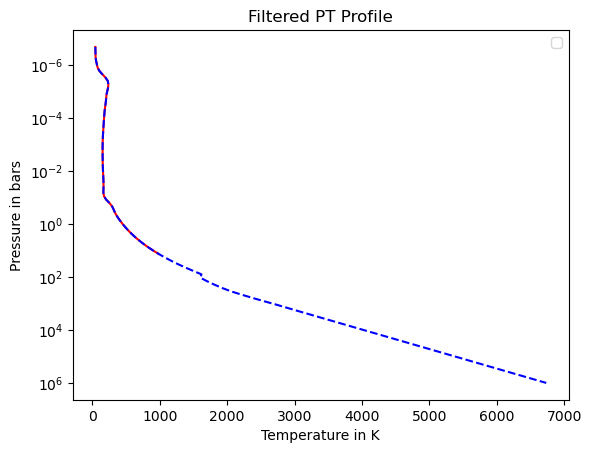

This should show the species you are excluding: O3
0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
     ... 
57    0.0
58    0.0
59    0.0
60    0.0
61    0.0
Name: O3, Length: 62, dtype: float64
This is the length of the grids created: 483, 483
pbot was calculated, there is H2Oaer and a cloud was implemented


In [8]:
rad_plan = 2.61
log10_metal = 3.5
tint = 155
semi_major = 1
ctoO = 0.01
Kzz = 5
sol_path = f'sol_{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}.pkl'
soleq_path = f'soleq_{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}.pkl'
phase_angle = 0
atmosphere_kwargs = {'exclude_mol': ['O3']} # What molecules do you want to exclude?

# wno, fpfs, alb, clouds, df_cld, df_cldfree = reflected_spectrum_planet_Sun(rad_plan=rad_plan, planet_metal=log10_metal, tint=tint, semi_major=semi_major, ctoO=ctoO, Kzz=Kzz, phase_angle=phase_angle, sol_path=sol_path, soleq_path=soleq_path, atmosphere_kwargs=atmosphere_kwargs, Photochem_file=True, outputfile=f'{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}_{phase_angle}_noO3')

/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db
<class 'numpy.ndarray'>
Length of pressure vs other element: 100 vs 100


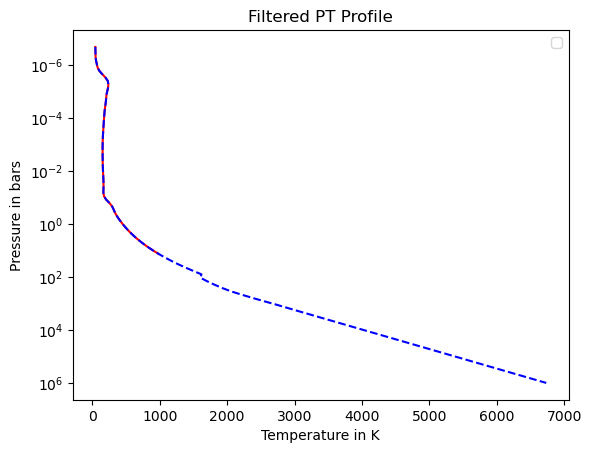

This should show the species you are excluding: O3
0     1.464338e-06
1     2.201826e-06
2     3.310737e-06
3     4.978131e-06
4     9.474415e-06
          ...     
57    3.967940e-14
58    3.466605e-13
59    2.746929e-12
60    1.835446e-11
61    1.043256e-10
Name: O3, Length: 62, dtype: float64
This is the length of the grids created: 483, 483
pbot was calculated, there is H2Oaer and a cloud was implemented


In [82]:
rad_plan = 2.61
log10_metal = 3.5
tint = 155
semi_major = 1
ctoO = 0.01
Kzz = 5
sol_path = f'sol_{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}.pkl'
soleq_path = f'soleq_{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}.pkl'
phase_angle = 0
kwarg_factor = 10
atmosphere_kwargs = {'exclude_mol': ['O3']} # What molecules do you want to multiply by the kwarg factor

wno, fpfs, alb, clouds, df_cld, df_cldfree = reflected_spectrum_planet_Sun(rad_plan=rad_plan, planet_metal=log10_metal, tint=tint, semi_major=semi_major, ctoO=ctoO, Kzz=Kzz, phase_angle=phase_angle, sol_path=sol_path, soleq_path=soleq_path,atmosphere_kwargs=atmosphere_kwargs, kwarg_factor=kwarg_factor, Photochem_file=True, outputfile=f'{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}_{phase_angle}_10xO3')

/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db
<class 'numpy.ndarray'>
Length of pressure vs other element: 100 vs 100


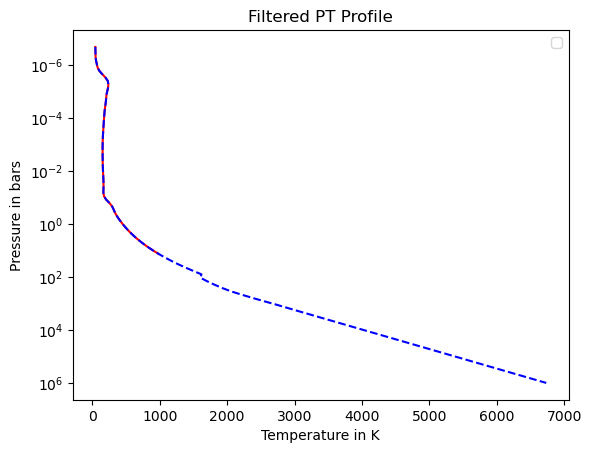

This should show the species you are excluding: O3
0     4.026928e-05
1     6.055021e-05
2     9.104526e-05
3     1.368986e-04
4     2.605464e-04
          ...     
57    1.091184e-12
58    9.533163e-12
59    7.554056e-11
60    5.047477e-10
61    2.868953e-09
Name: O3, Length: 62, dtype: float64
This is the length of the grids created: 483, 483
pbot was calculated, there is H2Oaer and a cloud was implemented


In [83]:
rad_plan = 2.61
log10_metal = 3.5
tint = 155
semi_major = 1
ctoO = 0.01
Kzz = 5
sol_path = f'sol_{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}.pkl'
soleq_path = f'soleq_{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}.pkl'
atmosphere_kwargs = {'exclude_mol': ['O3']} # What molecules do you want to multiply by the kwarg factor
phase_angle = 0
kwarg_factor = 275

wno, fpfs, alb, clouds, df_cld, df_cldfree = reflected_spectrum_planet_Sun(rad_plan=rad_plan, planet_metal=log10_metal, tint=tint, semi_major=semi_major, ctoO=ctoO, Kzz=Kzz, phase_angle=phase_angle, sol_path=sol_path, soleq_path=soleq_path, atmosphere_kwargs=atmosphere_kwargs, kwarg_factor=kwarg_factor, Photochem_file=True, outputfile=f'{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}_{phase_angle}_275xO3')

### Currently the following data is still based on an older RLS calculation that cut everything out T<1000. 

In [7]:
file_path = "data/RLS_results/RLS_2.61_3.5_155_1_0.01_5_0_noO3.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co_noO3 = pickle.load(file)
    #print(RLS_data_35m_001co_noO3['df_cldfree'])

file_path = "data/RLS_results/RLS_2.61_3.5_155_1_0.01_5_0_10xO3.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co_10xO3 = pickle.load(file)
    #print(RLS_data_35m_001co['df_cldfree'])

file_path = "data/RLS_results/RLS_2.61_3.5_155_1_0.01_5_0_275xO3.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co_275xO3 = pickle.load(file)
    #print(RLS_data_35m_001co['df_cldfree'])

file_path = "data/RLS_results/RLS_2.61_3.5_155_1_0.01_5_0.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co = pickle.load(file)
    #print(RLS_data_35m_001co['df_cldfree'])

Text(0.5, 1.0, 'Reflected Spectra ~3162x Metallicity, C/O 0.01x Solar K218b/G-Star')

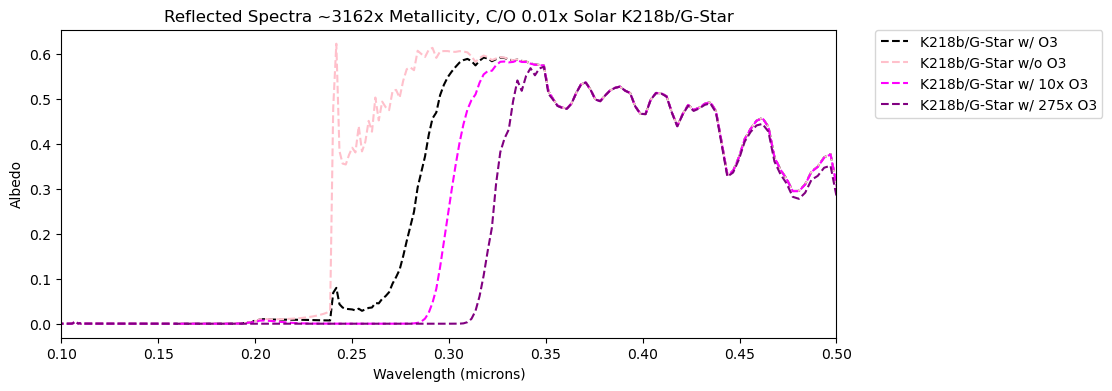

In [8]:
wno = RLS_data_35m_001co['wno']
fpfs = RLS_data_35m_001co['fpfs']
alb = RLS_data_35m_001co['alb']

wno_noO3 = RLS_data_35m_001co_noO3['wno']
fpfs_noO3 = RLS_data_35m_001co_noO3['fpfs']
alb_noO3 = RLS_data_35m_001co_noO3['alb']

wno_10xO3 = RLS_data_35m_001co_10xO3['wno']
fpfs_10xO3 = RLS_data_35m_001co_10xO3['fpfs']
alb_10xO3 = RLS_data_35m_001co_10xO3['alb']

wno_275xO3 = RLS_data_35m_001co_275xO3['wno']
fpfs_275xO3 = RLS_data_35m_001co_275xO3['fpfs']
alb_275xO3 = RLS_data_35m_001co_275xO3['alb']


fig, ax1 = plt.subplots(1, figsize=(10, 4))
ax1.plot(1e4/wno, alb, c='black', ls='--', lw=1.5, label='K218b/G-Star w/ O3')
ax1.plot(1e4/wno_noO3, alb_noO3, c='pink', ls='--', lw=1.5, label='K218b/G-Star w/o O3')
ax1.plot(1e4/wno_10xO3, alb_10xO3, c='magenta', ls='--', lw=1.5, label='K218b/G-Star w/ 10x O3')
ax1.plot(1e4/wno_275xO3, alb_275xO3, c='purple', ls='--', lw=1.5, label='K218b/G-Star w/ 275x O3')
ax1.set_xlim(0.1, 0.5)
#ax1.set_ylim(0, 0.35)
ax1.set_ylabel('Albedo')
ax1.set_xlabel('Wavelength (microns)')

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax1.set_title(f'Reflected Spectra ~3162x Metallicity, C/O 0.01x Solar K218b/G-Star')

## Compare Mini-Neptune Case to Modern Earth (how much ozone does my modern earth have in dobsoms, and what does the spectrum look like without ozone?)???
- Whole idea is to find the dobsons of the Earth by multiplying the total amount of molecules per cubic cm in each layer, multiplied by the mixing ratio.

In [9]:
def ozone_column_from_output(full_output):
    Xo3 = np.asarray(full_output['layer']['mixingratios']['O3'])          # unitless
    #print(Xo3)
    colden = np.asarray(full_output['layer']['column_density'])                  # g/cm^2
    #print(colden)
    mmw = np.asarray(full_output['layer']['mmw'])                                # g/mol
    #print(mmw)
    NA = 6.02214076e23                                                # molecules/mol
    o3_col = np.sum(Xo3 * (colden / mmw) * NA)                       # molecules/cm^2
    o3_DU = o3_col / 2.68678e16                                      # Dobson Units
    return o3_col, o3_DU

In [10]:
with h5py.File("data/Earth_results/Modern_earth_diff_phases.h5", "r") as f:
    #print(list(f.keys()))
    grp = f["phase_0.5236"]# example

    full_output = grp['df_cld']['full_output']

    o3_col, o3_DU = ozone_column_from_output(full_output)

    print(o3_col, o3_DU)

    #print(grp.keys())

    wno_modern_earth_defO3 = np.asarray(grp['wv'])
    alb_modern_earth_defO3 = np.asarray(grp['alb'])
    fpfs_modern_earth_defO3 = np.asarray(grp['fpfs'])

    
    
    #wv_modern_dict_0 = grp["wv"][:]         # loads only this array
    #alb_modern_dict_0 = grp["alb"][:]
    #fpfs_modern_dict_0 = grp["fpfs"][:]

    #print(list(grp["df_cld"].keys()))
    #df_cld_modern_dict_0 = grp["df_cld"]["full_output"]
    #print(list(df_cld_modern_dict_0.keys()))

1.4917214681252401e+19 555.2078949989356


### Change the Mixing Ratio of O3

In [74]:
df_mol_modern_earth = {
        "N2":0.79,
        "O2":0.21,
        "O3":0.5 * (7e-7),
        "H2O":3e-3,
        "CO2":300e-6,
        "CH4":1.7e-6
    }

In [75]:
opacity_file_path = "Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db"  
opacity_path=os.path.join(current_directory, opacity_file_path)
print(opacity_path)

/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db


In [76]:
def earth_spectrum(opacity_path=None, df_mol_earth=None, phase=None, atmosphere_kwargs={'key':None}, cloud_frac = 0.5):

    """
    Calculates the Modern Earth Reflected Spectrum at full phase around the same star (Sun). 

    Parameters:
    opacity_path: string
        This provides the path to the opacity file you wish to use (we recommend v3 from Batalha et. al. 2025 on zenodo titled "Resampled Opacity Database for PICASO".
    atmosphere_kwargs: 'key': value
        If you wish to exclude any molecules, you can create a key titled 'exclude_mol' and add a list of molecules you do not wish to computer the reflected spectra of.
    df_mol_earth: dictionary with allowable abundances of molecules from the period of Earth you want
        
        EXAMPLE:

        df_mol_earth = {"N2": 0.79,
            "O2": 0.21,
            "O3": 7e-7,
            "H2O": 3e-3,
            "CO2": 300e-6,
            "CH4": 1.7e-6
        }

    Results:
    wno: grid of 150 values
        This is something, idk.
    fpfs: grid of 150 values
        This is the relative flux of the planet and star (fp/fs). 
    albedo: grid of 150 values
        This is something, idk.
    
    """

    earth = jdi.inputs()
    
    # Phase angle 
    earth.phase_angle(phase, num_tangle=8, num_gangle=8) #radians
    
    # Define planet gravity
    earth.gravity(radius=1, radius_unit=jdi.u.Unit('R_earth'),
                 mass =1, mass_unit=jdi.u.Unit('M_earth')) #any astropy units available
    earth.approx(raman="none")
    
    # Define star (same as used in K218b grid calculations)
    stellar_radius = 1 # Solar radii
    stellar_Teff = 5778 # K
    stellar_metal = 0.0 # log10(metallicity)
    stellar_logg = 4.4 # log10(gravity), in cgs units
    opacity = jdi.opannection(filename_db=opacity_path, wave_range=[0.3,2.5])
    
    earth.star(opannection=opacity,temp=stellar_Teff,logg=stellar_logg,semi_major=1, metal=stellar_metal,
               semi_major_unit=u.Unit('au')) 

    # P-T-Composition
    nlevel = 90 
    P = np.logspace(-6, 0, nlevel)
    df_atmo = earth.TP_line_earth(P , nlevel = nlevel)
    df_pt_earth =  pd.DataFrame({
        'pressure':df_atmo['pressure'].values,
        'temperature':df_atmo['temperature'].values})

    if df_mol_earth == None:
        df_mol_earth_modern_default = pd.DataFrame({
                "N2":P*0+0.79,
                "O2":P*0+0.21,
                "O3":P*0+7e-7,
                "H2O":P*0+3e-3,
                "CO2":P*0+300e-6,
                "CH4":P*0+1.7e-6
            })
        
        df_atmo_earth = df_pt_earth.join(df_mol_earth_modern_default, how='inner')
        print(df_atmo_earth)

    else:
        df_mol_earth_grid_dict = {}
        df_mol_earth_grid = pd.DataFrame({})
        for key in df_mol_earth:
            df_mol_earth_grid_dict[key] = df_mol_earth[key] + (P*0)
            for key in df_mol_earth_grid_dict:
                df_mol_earth_grid[key] = pd.Series(df_mol_earth_grid_dict[key])

        df_atmo_earth = df_pt_earth.join(df_mol_earth_grid, how='inner')
        print(df_atmo_earth)

    print(atmosphere_kwargs)
    print(type(atmosphere_kwargs))
    
    if 'exclude_mol' in atmosphere_kwargs.keys():
        sp = atmosphere_kwargs['exclude_mol'][0]
        if sp in df_atmo_earth:
            df_atmo_earth[sp] *= 0

    else:
        df_atmo_earth = df_atmo_earth
            
    # earth.atmosphere(df=df_atmo_earth, **atmosphere_kwargs)
    
    earth.atmosphere(df=df_atmo_earth)
    earth.surface_reflect(0.1,opacity.wno)

    # Cloud free spectrum
    df_cldfree = earth.spectrum(opacity,calculation='reflected',full_output=True)

    # Clouds
    ptop = 0.6
    pbot = 0.7
    logdp = np.log10(pbot) - np.log10(ptop)  
    log_pbot = np.log10(pbot)
    earth.clouds(w0=[0.99], g0=[0.85], 
                 p = [log_pbot], dp = [logdp], opd=[10])

    # Cloud spectrum
    df_cld = earth.spectrum(opacity,full_output=True)

    # Average the two spectra
    wno, alb, fpfs, albedo = df_cldfree['wavenumber'],df_cldfree['albedo'],df_cldfree['fpfs_reflected'], df_cldfree['albedo']
    wno_c, alb_c, fpfs_c, albedo_c = df_cld['wavenumber'],df_cld['albedo'],df_cld['fpfs_reflected'], df_cld['albedo']
    _, albedo = jdi.mean_regrid(wno, (1 - cloud_frac)*albedo+cloud_frac*albedo_c,R=150)
    wno, fpfs = jdi.mean_regrid(wno, (1 - cloud_frac)*fpfs+cloud_frac*fpfs_c,R=150)
    

    return wno, fpfs, albedo, df_cld, df_cldfree

def make_case_earth(opacity_path=opacity_path, df_mol_earth=None, phase=0, species=None, cloud_frac=0.5):

    """
    This calculates a dictionary of wno, albedo, and fpfs results from earth_spectrum.

    Provide a list if you wish to limit the species calculated by the reflected light spectra.
    species = ['O2','H2O','CO2','O3','CH4']
    
    """
    res = {}
    res['all'] = earth_spectrum(opacity_path=opacity_path, df_mol_earth=df_mol_earth, phase=phase, cloud_frac=cloud_frac) # in order of wno, fpfs, alb, df_cld, df_cldfree
    
    if species is not None:
        for sp in species:
            tmp = earth_spectrum(opacity_path=opacity_path, atmosphere_kwargs={'exclude_mol': [sp]}, phase=phase, cloud_frac=cloud_frac)
            res[sp] = tmp[:2]
        return res

    else:
        return res

In [77]:
import numpy as np
import h5py
import pandas as pd

def save_array_or_string(group, key, arr):
    """
    Save numeric arrays, string arrays, or object arrays safely.
    If the array contains nested lists/objects, convert to groups recursively.
    """
    # If it's a numpy scalar
    if np.isscalar(arr):
        group.attrs[key] = arr
        return

    # Convert to numpy array if list/tuple
    if isinstance(arr, (list, tuple)):
        arr = np.array(arr, dtype=object)

    # If numeric array
    if np.issubdtype(arr.dtype, np.number):
        group.create_dataset(key, data=arr, compression="gzip", chunks=True)
    
    # If string array
    elif arr.dtype.kind in {"U", "S"}:
        dt = h5py.string_dtype(encoding="utf-8")
        data = np.array(arr.tolist(), dtype=object)  # force Python str
        group.create_dataset(key, data=data, dtype=dt)
    
    # If object array
    elif arr.dtype.kind == "O":
        # check if all elements are strings
        if all(isinstance(x, str) for x in arr.flat):
            dt = h5py.string_dtype(encoding="utf-8")
            data = np.array(arr.tolist(), dtype=object)
            group.create_dataset(key, data=data, dtype=dt)
        else:
            # Otherwise, create a group for each element
            subgrp = group.create_group(key)
            for i, val in enumerate(arr):
                subkey = f"{i}"
                # Recurse
                save_array_or_string(subgrp, subkey, val)
    
    else:
        raise TypeError(f"Cannot save array of dtype {arr.dtype} for key {key}")
        
def save_dict_to_hdf5(group, dictionary):

    for key, value in dictionary.items():
        key = str(key)

        # ---- Nested dictionary ----
        if isinstance(value, dict):
            subgrp = group.create_group(key)
            save_dict_to_hdf5(subgrp, value)

        # ---- Pandas DataFrame ----
        elif isinstance(value, pd.DataFrame):
            df_grp = group.create_group(key)
            df_grp.attrs["columns"] = list(value.columns)
            df_grp.attrs["index"] = value.index.to_numpy()
            for col in value.columns:
                col_data = value[col].to_numpy()
                save_array_or_string(df_grp, col, col_data)

        # ---- NumPy array ----
        elif isinstance(value, np.ndarray):
            save_array_or_string(group, key, value)

        # ---- List or tuple ----
        elif isinstance(value, (list, tuple)):
            arr = np.array(value)
            save_array_or_string(group, key, arr)

        # ---- Python string ----
        elif isinstance(value, str):
            dt = h5py.string_dtype(encoding="utf-8")
            group.create_dataset(key, data=value, dtype=dt)

        # ---- Scalar numeric ----
        elif np.isscalar(value):
            group.attrs[key] = value

        else:
            raise TypeError(f"Unsupported type for key '{key}': {type(value)}")

            
def calc_RSM_earth_phases(df_mol_earth=None, phase_earth=None, earth_type='Archean', cloud_frac = 0.5):

    if phase_earth is None:
        phase_earth = np.linspace(0, np.pi, 19)
        phase_angle = phase_earth[:-1]
    else:
        phase_angle = phase_earth

    if df_mol_earth is None:
        df_mol_earth = {
            "N2": 0.945,
            "CO2": 0.05,
            "CO": 0.0005,
            "CH4": 0.005,
            "H2O": 0.003
        }

    filename = f"{earth_type}_earth_diff_phases_cldfrac{cloud_frac}_{phase_angle}_noO3.h5"

    with h5py.File(filename, "w") as f:

        f.attrs["earth_type"] = earth_type
        f.attrs["num_phases"] = len(phase_angle)

        for phase in phase_angle:

            res_earth = make_case_earth(df_mol_earth=df_mol_earth, phase=phase, cloud_frac=cloud_frac)

            wv = res_earth['all'][0]
            fpfs = res_earth['all'][1]
            alb = res_earth['all'][2]
            df_cld = res_earth['all'][3]        # dictionary
            df_cldfree = res_earth['all'][4]    # dictionary

            phase_str = f"{phase:.4f}"
            grp = f.create_group(f"phase_{phase_str}")
            grp.attrs["phase_radians"] = phase

            # Save main arrays
            grp.create_dataset("wv", data=wv, compression="gzip", chunks=True)
            grp.create_dataset("fpfs", data=fpfs, compression="gzip", chunks=True)
            grp.create_dataset("alb", data=alb, compression="gzip", chunks=True)

            # Save nested dictionaries
            cld_grp = grp.create_group("df_cld")
            save_dict_to_hdf5(cld_grp, df_cld)

            cldfree_grp = grp.create_group("df_cldfree")
            save_dict_to_hdf5(cldfree_grp, df_cldfree)

    return print(f"{filename} recorded successfully.")

In [51]:
#calc_RSM_earth_phases(df_mol_earth=df_mol_modern_earth, earth_type='Modern', phase_earth=([0.52359878]))

    pressure  temperature    N2    O2            O3    H2O     CO2       CH4
0   0.000001   274.163889  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
1   0.000001   274.163889  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
2   0.000001   274.163889  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
3   0.000002   274.163889  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
4   0.000002   274.163889  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
..       ...          ...   ...   ...           ...    ...     ...       ...
85  0.537449   262.910544  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
86  0.627701   270.360248  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
87  0.733109   278.021043  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
88  0.856218   285.898910  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002
89  1.000000   294.000000  0.79  0.21  3.500000e-07  0.003  0.0003  0.000002

[90 rows x 8 columns]
{'key': None}
<class 'dict'>
Modern_earth_diff_phases

In [78]:
df_mol_modern_earth_zeroO3 = {
        "N2":0.79,
        "O2":0.21,
        "O3":0 * (7e-7),
        "H2O":3e-3,
        "CO2":300e-6,
        "CH4":1.7e-6
    }

In [55]:
#calc_RSM_earth_phases(df_mol_earth = df_mol_modern_earth_zeroO3, earth_type='Modern', phase_earth=([0.52359878]))

    pressure  temperature    N2    O2   O3    H2O     CO2       CH4
0   0.000001   274.163889  0.79  0.21  0.0  0.003  0.0003  0.000002
1   0.000001   274.163889  0.79  0.21  0.0  0.003  0.0003  0.000002
2   0.000001   274.163889  0.79  0.21  0.0  0.003  0.0003  0.000002
3   0.000002   274.163889  0.79  0.21  0.0  0.003  0.0003  0.000002
4   0.000002   274.163889  0.79  0.21  0.0  0.003  0.0003  0.000002
..       ...          ...   ...   ...  ...    ...     ...       ...
85  0.537449   262.910544  0.79  0.21  0.0  0.003  0.0003  0.000002
86  0.627701   270.360248  0.79  0.21  0.0  0.003  0.0003  0.000002
87  0.733109   278.021043  0.79  0.21  0.0  0.003  0.0003  0.000002
88  0.856218   285.898910  0.79  0.21  0.0  0.003  0.0003  0.000002
89  1.000000   294.000000  0.79  0.21  0.0  0.003  0.0003  0.000002

[90 rows x 8 columns]
{'key': None}
<class 'dict'>
Modern_earth_diff_phases_cldfrac0.5_[0.52359878]_noO3.h5 recorded successfully.


In [11]:
with h5py.File("Modern_earth_diff_phases_cldfrac0.5_[0.52359878]_halfO3.h5", "r") as f:
    #print(list(f.keys()))
    grp = f["phase_0.5236"]# example

    full_output = grp['df_cld']['full_output']

    o3_col, o3_DU = ozone_column_from_output(full_output)

    print(o3_col, o3_DU)

    wv_modern_dict_halfO3 = np.asarray(grp["wv"][:])         # loads only this array
    alb_modern_dict_halfO3 = np.asarray(grp["alb"][:])
    fpfs_modern_dict_halfO3 = np.asarray(grp["fpfs"][:])

    #print(list(grp["df_cld"].keys()))
    #df_cld_modern_dict_0 = grp["df_cld"]["full_output"]
    #print(list(df_cld_modern_dict_0.keys()))

with h5py.File("Modern_earth_diff_phases_cldfrac0.5_[0.52359878]_noO3.h5", "r") as f:
    #print(list(f.keys()))
    grp = f["phase_0.5236"]# example

    full_output = grp['df_cld']['full_output']

    o3_col, o3_DU = ozone_column_from_output(full_output)

    print(o3_col, o3_DU)

    wv_modern_dict_noO3 = np.asarray(grp["wv"][:])        # loads only this array
    alb_modern_dict_noO3 = np.asarray(grp["alb"][:])
    fpfs_modern_dict_noO3 = np.asarray(grp["fpfs"][:])

    #print(list(grp["df_cld"].keys()))
    #df_cld_modern_dict_0 = grp["df_cld"]["full_output"]
    #print(list(df_cld_modern_dict_0.keys()))

7.45861168397039e+18 277.6041091555836
0.0 0.0


Text(0.5, 1.0, 'Reflected Spectra ~3162x Metallicity, C/O 0.01x Solar K218b/G-Star')

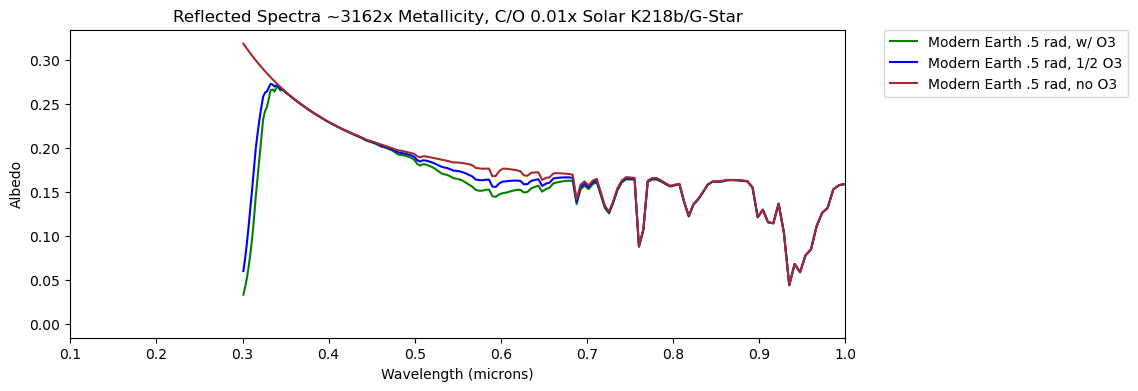

In [13]:
wno = RLS_data_35m_001co['wno']
fpfs = RLS_data_35m_001co['fpfs']
alb = RLS_data_35m_001co['alb']

wno_noO3 = RLS_data_35m_001co_noO3['wno']
fpfs_noO3 = RLS_data_35m_001co_noO3['fpfs']
alb_noO3 = RLS_data_35m_001co_noO3['alb']

wno_10xO3 = RLS_data_35m_001co_10xO3['wno']
fpfs_10xO3 = RLS_data_35m_001co_10xO3['fpfs']
alb_10xO3 = RLS_data_35m_001co_10xO3['alb']

wno_275xO3 = RLS_data_35m_001co_275xO3['wno']
fpfs_275xO3 = RLS_data_35m_001co_275xO3['fpfs']
alb_275xO3 = RLS_data_35m_001co_275xO3['alb']

# These are for Modern Earth at 0.5 radians, regular O3 levels (7e-7)
#wno_modern_earth_defO3 = list(grp['wv'])
#alb_modern_earth_defO3 = list(grp['alb'])
#fpfs_modern_earth_defO3 = list(grp['fpfs'])

fig, ax1 = plt.subplots(1, figsize=(10, 4))

# Plotted Mini-Neptune Cases
#ax1.plot(1e4/wno, alb, c='black', ls='--', lw=1.5, label='K218b/G-Star w/ O3')
#ax1.plot(1e4/wno_noO3, alb_noO3, c='pink', ls='--', lw=1.5, label='K218b/G-Star w/o O3')
#ax1.plot(1e4/wno_10xO3, alb_10xO3, c='magenta', ls='--', lw=1.5, label='K218b/G-Star w/ 10x O3')
#ax1.plot(1e4/wno_275xO3, alb_275xO3, c='purple', ls='--', lw=1.5, label='K218b/G-Star w/ 275x O3')

# Plotted Earth Cases
ax1.plot(1e4/wno_modern_earth_defO3, alb_modern_earth_defO3, c='green', ls='-', lw=1.5, label='Modern Earth .5 rad, w/ O3')
ax1.plot(1e4/wv_modern_dict_halfO3, alb_modern_dict_halfO3, c='blue', ls='-', lw=1.5, label='Modern Earth .5 rad, 1/2 O3')
ax1.plot(1e4/wv_modern_dict_noO3, alb_modern_dict_noO3, c='brown', ls='-', lw=1.5, label='Modern Earth .5 rad, no O3')
ax1.set_xlim(0.1, 1)
#ax1.set_ylim(0, 0.35)
ax1.set_ylabel('Albedo')
ax1.set_xlabel('Wavelength (microns)')

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax1.set_title(f'Reflected Spectra ~3162x Metallicity, C/O 0.01x Solar K218b/G-Star')